In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape, Dropout

In [4]:
df = pd.read_csv("ASIANPAINT.csv")

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [6]:
features = ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close',
            'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

In [7]:
df = df[['Date'] + features].dropna()
dates = df['Date'].values
data = df[features].values

In [8]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [9]:
n_past = 10
n_future = 5

In [10]:
X, y = [], []
for i in range(n_past, len(data_scaled) - n_future + 1):
    X.append(data_scaled[i - n_past:i, :])
    y.append(data_scaled[i:i + n_future, :])

X, y = np.array(X), np.array(y)


In [11]:
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [12]:
dates_test = dates[n_past + split_idx : n_past + split_idx + len(X_test)]

In [13]:
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(n_past, len(features)), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(n_future * len(features)))
model.add(Reshape((n_future, len(features))))

model.compile(optimizer='adam', loss='mse')

print("Training Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)


Training Model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0494 - val_loss: 0.0046
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0098 - val_loss: 0.0034
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0063 - val_loss: 0.0024
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0046 - val_loss: 0.0023
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0040 - val_loss: 0.0024
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0040 - val_loss: 0.0023
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032 - val_loss: 0.002

In [14]:
print("\nEvaluating Model...")
predictions = model.predict(X_test)

pred_flat = predictions.reshape(-1, len(features))
y_test_flat = y_test.reshape(-1, len(features))

pred_inv = scaler.inverse_transform(pred_flat)
y_test_inv = scaler.inverse_transform(y_test_flat)


Evaluating Model...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [15]:
mse = mean_squared_error(y_test_inv, pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, pred_inv)

In [16]:
print(f"\n--- Model Performance ---")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


--- Model Performance ---
MSE  : 12952243921245090276679090176.0000
RMSE : 113807925564281.7344
MAE  : 24620724453088.5859


In [17]:
close_idx = features.index('Close')

actual_close = y_test[:, 0, close_idx]
pred_close = predictions[:, 0, close_idx]

In [19]:
dummy_actual = np.zeros((len(actual_close), len(features)))
dummy_actual[:, close_idx] = actual_close
actual_close_inv = scaler.inverse_transform(dummy_actual)[:, close_idx]

dummy_pred = np.zeros((len(pred_close), len(features)))
dummy_pred[:, close_idx] = pred_close
pred_close_inv = scaler.inverse_transform(dummy_pred)[:, close_idx]


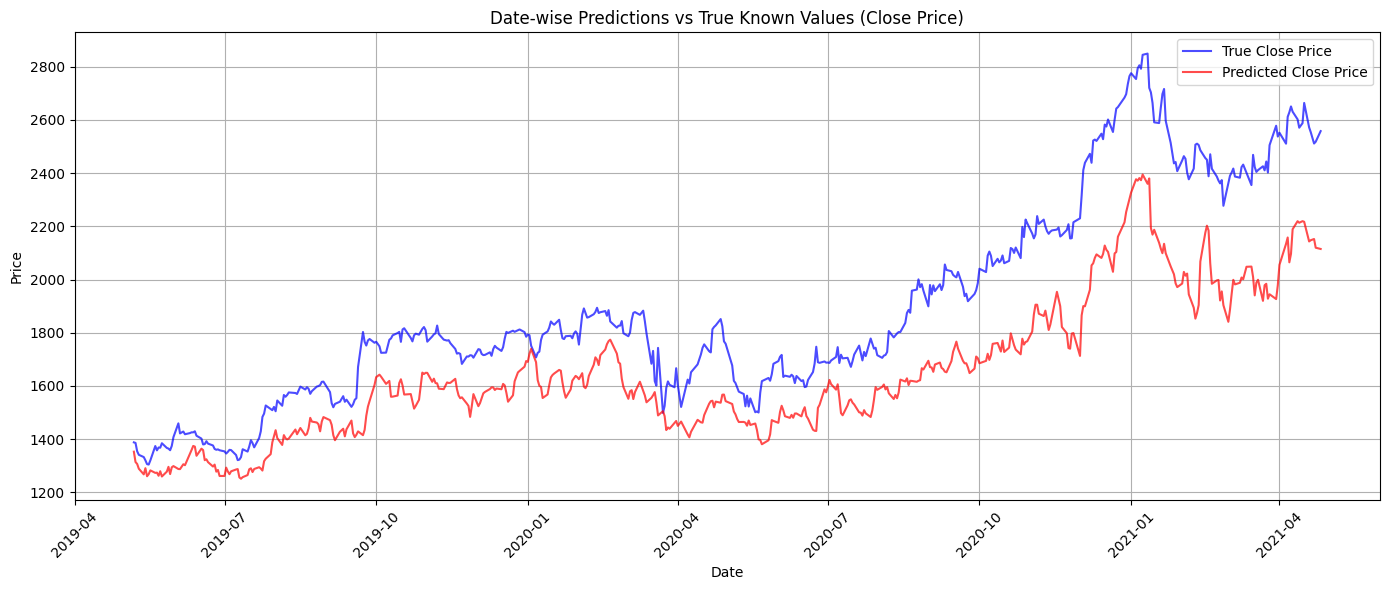

In [22]:

plt.figure(figsize=(14, 6))
plt.plot(dates_test, actual_close_inv, label='True Close Price', color='blue', alpha=0.7)
plt.plot(dates_test, pred_close_inv, label='Predicted Close Price', color='red', alpha=0.7)
plt.title('Date-wise Predictions vs True Known Values (Close Price)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()